[Kaggle Plasma lipidomics in Alzheimer's disease](https://www.kaggle.com/datasets/fereshtehjozaghkar/plasma-lipidomics-in-alzheimers-disease)

## Data Card

### About Datset

**Introduction**
Alzheimer's disease (AD) is a progressive neurodegenerative disorder that affects humans. It is typically characterized by cognitive impairment, which affects speech, behavior, and visual orientation. As cognitive capabilities decline, daily activities become more challenging, disabilities are experienced, and death occurs. Alzheimer's disease (AD) is strongly associated with abnormal lipid metabolism.
This dataset contains 213 plasma samples, including 20 controls, 89 samples from individuals with mild cognitive impairment, and 104 samples from individuals with Alzheimer's disease. Furthermore, the dataset includes information on age, sex, cognitive evaluation results, and cerebrospinal fluid biomarkers indicative of Alzheimer's disease.

**Authors**
Gerard Piñol-Ripoll, Farida Dakterzada, Joaquim Sol, Mariona Jové, Reinald Pamplona

**- Creative Commons License of the dataset:**
Attribution-NonCommercial-NoDerivatives (BY-NC-ND)

**- Dataset Digital Object Identifier (DOI):**
https://doi.org/10.34810/data614

**- Publications related to the dataset:**
Dakterzada, F., Jové, M., Huerto, R., Carnes, A., Sol, J., Pamplona, R., & Piñol-Ripoll, G. (2023). Changes in Plasma Neutral and Ether-Linked Lipids Are Associated with The Pathology and Progression of Alzheimer’s Disease. Aging and Disease, 14(5), 1728.

## Mayo Clinic
[Mayo Clinic](https://newsnetwork.mayoclinic.org/discussion/mayo-clinic-scientists-create-tool-to-predict-alzheimers-risk-years-before-symptoms-begin/)

Predicting Alzheimer's disease
Alzheimer's disease is marked by two key proteins in the brain: amyloid, which forms plaques, and tau, which forms tangles. Drugs recently approved by the Food and Drug Administration remove amyloid from the brain and can slow the rate of disease progression for people with MCI or mild dementia.

Photo of Dr. Clifford Jack, Jr.
Clifford Jack, Jr., M.D.
"What's exciting now is that we're looking even earlier — before symptoms begin — to see if we can predict who might be at greatest risk of developing cognitive problems in the future," says Clifford Jack, Jr., M.D., radiologist and lead author of the study.

The new prediction model combined several factors, including age, sex, genetic risk as associated with APOE genotype and brain amyloid levels detected on PET scans. Using the data, researchers can calculate an individual's likelihood of developing MCI or dementia within 10 years or over the predicted lifetime. Of all the predictors evaluated, the brain amyloid levels detected on PET scans was the predictor with the largest effect for lifetime risk of both MCI and dementia.

In [1]:
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import plotly.express as px
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
#from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
%matplotlib inline

In [2]:
df = pd.read_csv("data/plasma_lipidomics.csv")

## Data Analysis

In [3]:
df.head()

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months)
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN


In [4]:
len(df)

212

In [43]:
def histogram(label,rotation=None):
    ax = sns.histplot(data=df,x=label,hue=label,legend=False, shrink=.9)
    if rotation:
        ax.tick_params(axis='x', labelrotation=rotation)
    # Add the counts on top of each bar automatically
    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    image_title = label.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.show()

In [41]:
def histogram_totals(totals,title,xlabel):
    labels = ['Yes', 'No']   
    # 2. Create the bar plot
    plt.figure(figsize=(6, 4))
    ax = sns.barplot(x=labels, y=totals, palette=['#a1c9f4', '#ffb482'])
    for container in ax.containers:
            ax.bar_label(container, fmt=lambda x: str(int(x)) if x > 0 else '')
    # 3. Add labels and show
    plt.title(title)
    image_title = title.replace(" ", "_")
    plt.savefig(image_title, dpi=300, bbox_inches="tight")
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.show()

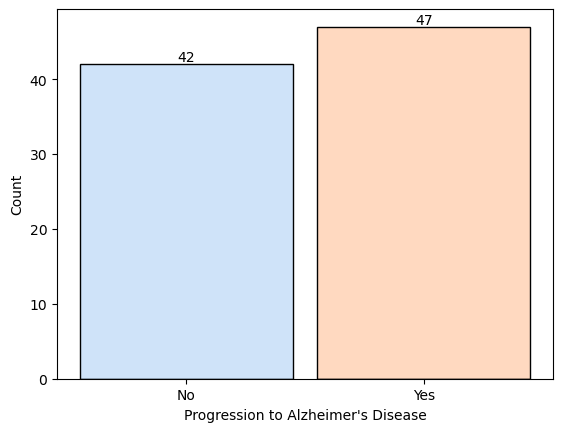

In [44]:
histogram("Progression to Alzheimer's Disease")

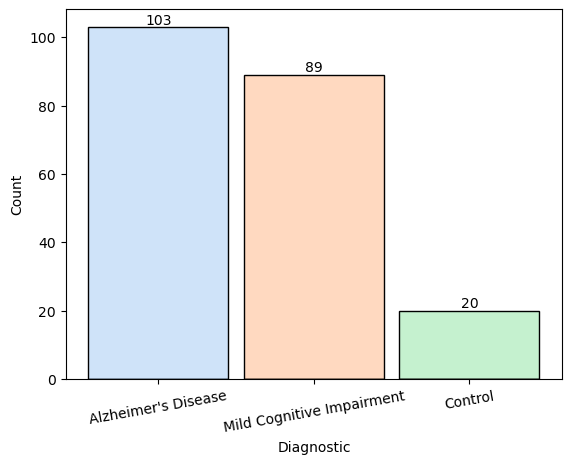

In [45]:
histogram("Diagnostic",rotation=10)

Exploring the relationships between Diagnostic and the key indicator "Progression to Alzeimers's Disease". 

In [9]:
#APOE4, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL)

In [10]:
overlap_yes = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == 'Mild Cognitive Impairment') & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 47
Non-MCI patients with Progression = No: 42


In [11]:
totals =[len(overlap_yes), len(overlap_no)]

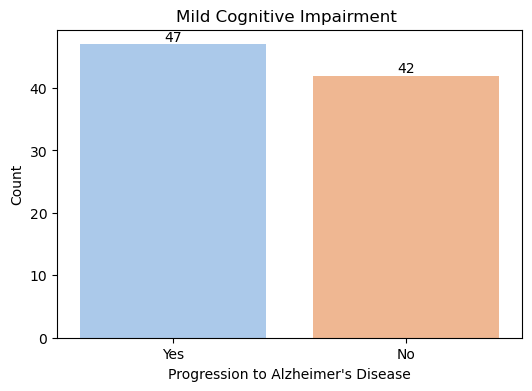

In [12]:
histogram_totals(totals=totals, title="Mild Cognitive Impairment ",xlabel="Progression to Alzheimer's Disease")

In [51]:
overlap_yes = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Alzheimer's Disease") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))


Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [54]:
df[df['Diagnostic'] == "Alzheimer's Disease"]

,Sample,Diagnostic,Sex,Age,MMSE,CSF Amyloid (pg/mL),CSF Total tau (pg/mL),CSF Phosphorylated tau (pg/mL),APOE4,Progression to Alzheimer's Disease,Progression time (months),APOE4_bin,Sex_bin
0,1,Alzheimer's Disease,Female,68,26,688.0,369.0,107.0,Yes,NaN,NaN,1,0
1,2,Alzheimer's Disease,Female,66,22,489.0,482.0,176.0,Yes,NaN,NaN,1,0
2,3,Alzheimer's Disease,Female,72,23,509.0,329.0,114.0,Yes,NaN,NaN,1,0
3,4,Alzheimer's Disease,Male,73,25,544.0,482.0,80.0,No,NaN,NaN,0,1
4,5,Alzheimer's Disease,Female,75,15,303.0,806.0,120.0,No,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,Alzheimer's Disease,Female,79,19,395.0,377.0,54.8,No,NaN,NaN,0,0
100,101,Alzheimer's Disease,Female,71,28,556.0,257.0,48.1,Yes,NaN,NaN,1,0
101,102,Alzheimer's Disease,Female,70,25,354.0,312.0,53.8,Yes,NaN,NaN,1,0
102,103,Alzheimer's Disease,Male,79,25,755.0,685.0,86.3,No,NaN,NaN,0,1


In [14]:
overlap_yes = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'Yes')]
overlap_no  = df[(df['Diagnostic'] == "Control") & (df["Progression to Alzheimer's Disease"] == 'No')]

print("Non-MCI patients with Progression = Yes:", len(overlap_yes))
print("Non-MCI patients with Progression = No:", len(overlap_no))

Non-MCI patients with Progression = Yes: 0
Non-MCI patients with Progression = No: 0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure grid with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot a different column on each axis
sns.histplot(data=iris, x="sepal_length", ax=axes[0], color="blue")
sns.histplot(data=iris, x="sepal_width", ax=axes[1], color="orange")
sns.histplot(data=iris, x="petal_length", ax=axes[2], color="green")

# Tighten the layout to avoid overlaps
plt.tight_layout()
plt.show()

There are no patients who's diagnostic is 'Alzheimer's Disease' or 'Control' "Progression to Alzheimer's Disease"

Therefore are two we will only consider are "Mild Cognitive Impairment" and "Progression to Alzheimer's Disease" Yes or No

We are going to look at the Mayo Clinic's hypothesis, and APOE4, CSF Phosphorylated tau (pg/mL), CSF Total tau (pg/mL), CSF Amyloid (pg/mL)

Test each value with the same metric - StandardScaler/LogistitRegression, and once the best parameters are determined, we pick the best classifier method.

In [15]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score

We have a problem, some of the Mild Cognitive Impairments have Nan APOE4 values.
So we are going to replace the Nan values with the most common APOE4 value or mode which is 'No'
Then we covert the APOE4 and Progression to Alzheimer's Disease Yes/No to 1/0

# APOE4

In [16]:
# Isolate the 'Mild Cognitive Impairment' set
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
# Determine the mode
apoe4_mode = mci['APOE4'].mode()[0]
# Fill all Nan value with 'No'
mci['APOE4'] = mci['APOE4'].fillna(apoe4_mode)
# Convert Yes/No to 1/0
mci['APOE4_bin'] = (mci['APOE4'] == 'Yes').astype(int)

# Create the target
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
# X is APOE4
X = mci[['APOE4_bin']]


In [19]:

def evaluate_performance(terms, X,y):
    # ---- 5-fold cross-validation, honest out-of-fold predictions ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    
    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    
    # ---- Confusion matrix ----
    terms = ' '.join(terms)
    print(f"Predicing 'Progression to Alzheimer's Disease' from {terms}\n")
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    
    # ---- Precision, recall, F1, accuracy, AUC ----
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    print('Accuracy:', accuracy_score(y, y_pred))
    print('AUC:', roc_auc_score(y, y_proba))

In [21]:
evaluate_performance(['APOE4'],X,y)

Predicing 'Progression to Alzheimer's Disease' from APOE4

             Pred: No  Pred: Yes
Actual: No         34          8
Actual: Yes        17         30
                precision    recall  f1-score   support

No progression      0.667     0.810     0.731        42
    Progressed      0.789     0.638     0.706        47

      accuracy                          0.719        89
     macro avg      0.728     0.724     0.719        89
  weighted avg      0.732     0.719     0.718        89

Accuracy: 0.7191011235955056
AUC: 0.6694528875379938


## 'CSF Amyloid (pg/mL)'

In [22]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)


mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)']]


In [23]:
evaluate_performance(['CSF Amyloid (pg/mL)'],X,y)

Predicing 'Progression to Alzheimer's Disease' from CSF Amyloid (pg/mL)

             Pred: No  Pred: Yes
Actual: No         25         17
Actual: Yes         8         39
                precision    recall  f1-score   support

No progression      0.758     0.595     0.667        42
    Progressed      0.696     0.830     0.757        47

      accuracy                          0.719        89
     macro avg      0.727     0.713     0.712        89
  weighted avg      0.725     0.719     0.715        89

Accuracy: 0.7191011235955056
AUC: 0.7510131712259374


## CSF Total tau (pg/mL)'

In [24]:
parameter = 'CSF Total tau (pg/mL)'
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)


mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Total tau (pg/mL)']]


In [25]:
evaluate_performance([parameter],X,y)

Predicing 'Progression to Alzheimer's Disease' from CSF Total tau (pg/mL)

             Pred: No  Pred: Yes
Actual: No         33          9
Actual: Yes        16         31
                precision    recall  f1-score   support

No progression      0.673     0.786     0.725        42
    Progressed      0.775     0.660     0.713        47

      accuracy                          0.719        89
     macro avg      0.724     0.723     0.719        89
  weighted avg      0.727     0.719     0.719        89

Accuracy: 0.7191011235955056
AUC: 0.7272036474164133


## Tau

In [26]:

df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 

amyloid_median = mci['CSF Phosphorylated tau (pg/mL)'].median()
mci['CSF Phosphorylated tau (pg/mL)'] = mci['CSF Phosphorylated tau (pg/mL)'].fillna(amyloid_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Phosphorylated tau (pg/mL)']]


In [27]:
evaluate_performance(['CSF Phosphorylated tau (pg/mL)'],X,y)

Predicing 'Progression to Alzheimer's Disease' from CSF Phosphorylated tau (pg/mL)

             Pred: No  Pred: Yes
Actual: No         23         19
Actual: Yes        13         34
                precision    recall  f1-score   support

No progression      0.639     0.548     0.590        42
    Progressed      0.642     0.723     0.680        47

      accuracy                          0.640        89
     macro avg      0.640     0.636     0.635        89
  weighted avg      0.640     0.640     0.637        89

Accuracy: 0.6404494382022472
AUC: 0.7155521783181358


## Tau and Total Tau

In [28]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 

amyloid_median = mci['CSF Phosphorylated tau (pg/mL)'].median()
mci['CSF Phosphorylated tau (pg/mL)'] = mci['CSF Phosphorylated tau (pg/mL)'].fillna(amyloid_median)

amyloid_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(amyloid_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Phosphorylated tau (pg/mL)', 'CSF Total tau (pg/mL)']]

In [29]:
evaluate_performance(['CSF Phosphorylated tau (pg/mL)', 'CSF Total tau (pg/mL)'],X,y)

Predicing 'Progression to Alzheimer's Disease' from CSF Phosphorylated tau (pg/mL) CSF Total tau (pg/mL)

             Pred: No  Pred: Yes
Actual: No         33          9
Actual: Yes        16         31
                precision    recall  f1-score   support

No progression      0.673     0.786     0.725        42
    Progressed      0.775     0.660     0.713        47

      accuracy                          0.719        89
     macro avg      0.724     0.723     0.719        89
  weighted avg      0.727     0.719     0.719        89

Accuracy: 0.7191011235955056
AUC: 0.7206180344478218


### Tau just above random, Total Tau alone is better

## AmyLoid and Total Tau

In [30]:
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy() 
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)

tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)']]

In [31]:
evaluate_performance(['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)'],X,y)

Predicing 'Progression to Alzheimer's Disease' from CSF Amyloid (pg/mL) CSF Total tau (pg/mL)

             Pred: No  Pred: Yes
Actual: No         29         13
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.725     0.690     0.707        42
    Progressed      0.735     0.766     0.750        47

      accuracy                          0.730        89
     macro avg      0.730     0.728     0.729        89
  weighted avg      0.730     0.730     0.730        89

Accuracy: 0.7303370786516854
AUC: 0.8011651469098278


**'CSF Amyloid (pg/mL)' and'CSF Total tau (pg/mL)' has the best accuracy**

### Given 'CSF Amyloid (pg/mL)' and'CSF Total tau (pg/mL)', what's the best classification algorithm?

In [65]:
import pandas as pd, numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:

def evaluate_pipelines(X,y,model):
    # ---- 5-fold cross-validation, honest out-of-fold predictions ----
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    y_pred = cross_val_predict(model[1], X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model[1], X, y, cv=cv, method='predict_proba')[:, 1]
    
    # ---- Confusion matrix ----
    terms = ' '.join(['CSF Amyloid (pg/mL)','CSF Total tau (pg/mL)'])
    print(f"Predicing 'Progression to Alzheimer's Disease' from {terms} with {model[0]} classifier" )

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    
    # ---- Precision, recall, F1, accuracy, AUC ----
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    print('Accuracy:', accuracy_score(y, y_pred))
    print('AUC:', roc_auc_score(y, y_proba))
    print('Recall (Progressed):', recall_score(y, y_pred))   # <-- new line

In [67]:
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))]),
    'Random Forest':        RandomForestClassifier(n_estimators=300, random_state=42),
    'SVM (RBF)':            Pipeline([('sc', StandardScaler()), ('clf', SVC(probability=True, random_state=42))]),
    'Gradient Boosting':    GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors':  Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier())]),
    'LDA':                  Pipeline([('sc', StandardScaler()), ('clf', LinearDiscriminantAnalysis())]),
    'Naive Bayes':          Pipeline([('sc', StandardScaler()), ('clf', GaussianNB())]),
}
for model in models.items():
    print(model[0])
    evaluate_pipelines(X,y,model)

Logistic Regression
Predicing 'Progression to Alzheimer's Disease' from CSF Amyloid (pg/mL) CSF Total tau (pg/mL) with Logistic Regression classifier
             Pred: No  Pred: Yes
Actual: No         29         13
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.725     0.690     0.707        42
    Progressed      0.735     0.766     0.750        47

      accuracy                          0.730        89
     macro avg      0.730     0.728     0.729        89
  weighted avg      0.730     0.730     0.730        89

Accuracy: 0.7303370786516854
AUC: 0.8011651469098278
Recall (Progressed): 0.7659574468085106
Random Forest
Predicing 'Progression to Alzheimer's Disease' from CSF Amyloid (pg/mL) CSF Total tau (pg/mL) with Random Forest classifier
             Pred: No  Pred: Yes
Actual: No         33          9
Actual: Yes        15         32
                precision    recall  f1-score   support

No progression      0.688

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---- Build mci and the two-feature X, y (same as before) ----
df = pd.read_csv("data/plasma_lipidomics.csv")
cols = ['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']
for col in cols:
    df[col] = df.groupby('Diagnostic')[col].transform(lambda s: s.fillna(s.median()))

mci = df[df.Diagnostic == 'Mild Cognitive Impairment'].copy()
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[cols]

# ---- Run the permutation test: 1000 shuffles of y, refit each time ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])

score, perm_scores, pvalue = permutation_test_score(
    model, X, y, cv=cv, scoring='roc_auc',
    n_permutations=1000, random_state=42, n_jobs=-1
)

print('Observed AUC:', score)
print('sklearn p-value:', pvalue)

# ---- Manually verify how that p-value is actually computed ----

# Step 1: count how many of the 1000 shuffled AUCs are >= the real AUC
count_as_extreme = np.sum(perm_scores >= score)
print('Count of shuffles at least as extreme:', count_as_extreme)

# Step 2: the naive version -- just divide by the number of permutations
naive_p = count_as_extreme / len(perm_scores)
print('Naive p-value:', naive_p)

# Step 3: the actual formula -- add 1 to numerator AND denominator
corrected_p = (count_as_extreme + 1) / (len(perm_scores) + 1)
print('Corrected p-value:', corrected_p)

Observed AUC: 0.8099999999999999
sklearn p-value: 0.000999000999000999
Count of shuffles at least as extreme: 0
Naive p-value: 0.0
Corrected p-value: 0.000999000999000999


In [36]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ---- Load and clean everything (same as before) ----
df = pd.read_csv('data/plasma_lipidomics.csv')
biomarker_cols = ['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)', 'CSF Phosphorylated tau (pg/mL)']
for col in biomarker_cols:
    df[col] = df.groupby('Diagnostic')[col].transform(lambda s: s.fillna(s.median()))
df['APOE4'] = df.groupby('Diagnostic')['APOE4'].transform(lambda s: s.fillna(s.mode()[0]))
df['APOE4_bin'] = (df['APOE4'] == 'Yes').astype(int)
df['Sex_bin'] = (df['Sex'] == 'Male').astype(int)

mci = df[df.Diagnostic == 'Mild Cognitive Impairment'].copy()
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---- Every feature (or combo) you've tested, run through the same permutation test ----
feature_sets = {
    'Age':                 ['Age'],
    'Sex':                 ['Sex_bin'],
    'MMSE':                ['MMSE'],
    'APOE4':               ['APOE4_bin'],
    'CSF Amyloid':         ['CSF Amyloid (pg/mL)'],
    'CSF Total tau':       ['CSF Total tau (pg/mL)'],
    'Amyloid + Total tau': ['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)'],
}

results = []
for name, feats in feature_sets.items():
    X = mci[feats]
    model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
    score, perm_scores, pvalue = permutation_test_score(
        model, X, y, cv=cv, scoring='roc_auc',
        n_permutations=1000, random_state=42, n_jobs=-1
    )
    results.append({'Feature(s)': name, 'AUC': round(score, 3), 'p-value': round(pvalue, 4),
                     'Significant (p<0.05)': 'Yes' if pvalue < 0.05 else 'No'})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

         Feature(s)   AUC  p-value Significant (p<0.05)
                Age 0.550   0.3656                   No
                Sex 0.524   0.5215                   No
               MMSE 0.640   0.0360                  Yes
              APOE4 0.727   0.0010                  Yes
        CSF Amyloid 0.782   0.0010                  Yes
      CSF Total tau 0.728   0.0010                  Yes
Amyloid + Total tau 0.810   0.0010                  Yes
